<a href="https://colab.research.google.com/github/Anshulmohan27/Machine_Learning/blob/main/Learning_ML_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

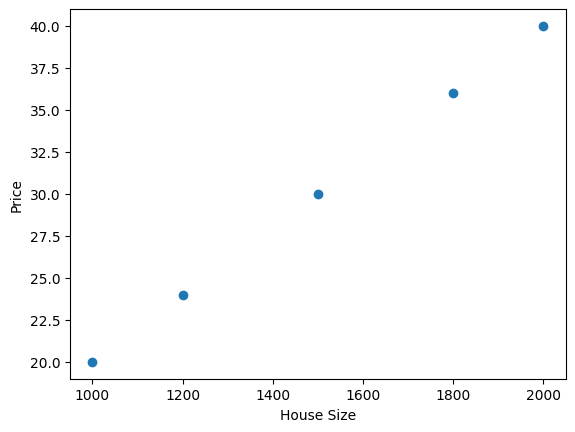

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1000, 1200, 1500, 1800, 2000])
y = np.array([20, 24, 30, 36, 40])

plt.scatter(x, y)
plt.xlabel("House Size")
plt.ylabel("Price")
plt.show()

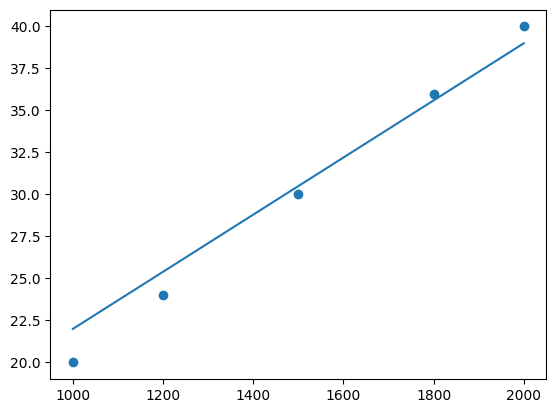

In [ ]:
w = 0.017
b = 5

prediction = w * x + b

plt.scatter(x, y)
plt.plot(x, prediction)
plt.show()

In [ ]:
errors = y - prediction

print(errors)

[-2.  -1.4 -0.5  0.4  1. ]


In [ ]:
print(np.sum(errors))

-2.500000000000007


In [ ]:
mae = np.mean(np.abs(errors))
mse = np.mean(errors ** 2)

print("MAE:", mae)
print("MSE:", mse)

MAE: 1.060000000000001
MSE: 1.4740000000000018


Suppose you're building software that predicts apartment prices.

Would you rather the model:

make many small mistakes, or
make one prediction that's ₹1 crore off?

Most people would choose the first. A single catastrophic prediction can be much more harmful.

By squaring errors, MSE makes those large mistakes much more expensive during training, so the model is pushed to reduce them.

This is one reason MSE is so widely used.

Taking the mean makes the error independent of dataset size, allowing us to compare models trained on different amounts of data.

In [ ]:
def cost_function(y_true, y_pred):
    errors = y_true - y_pred
    squared_errors = errors ** 2
    cost = np.mean(squared_errors)
    return cost

print(cost_function(y, prediction))

1.4740000000000018


There exists some value of w that gives the lowest possible cost.

We call this the optimal parameter.

In [ ]:
w = 0.010
b = 5

for i in range(20):
    prediction = w * x + b
    cost = cost_function(y, prediction)

    print(f"w = {w:.3f}, Cost = {cost:.3f}")

    w += 0.001

w = 0.010, Cost = 113.600
w = 0.011, Cost = 83.266
w = 0.012, Cost = 57.704
w = 0.013, Cost = 36.914
w = 0.014, Cost = 20.896
w = 0.015, Cost = 9.650
w = 0.016, Cost = 3.176
w = 0.017, Cost = 1.474
w = 0.018, Cost = 4.544
w = 0.019, Cost = 12.386
w = 0.020, Cost = 25.000
w = 0.021, Cost = 42.386
w = 0.022, Cost = 64.544
w = 0.023, Cost = 91.474
w = 0.024, Cost = 123.176
w = 0.025, Cost = 159.650
w = 0.026, Cost = 200.896
w = 0.027, Cost = 246.914
w = 0.028, Cost = 297.704
w = 0.029, Cost = 353.266


Suppose the best slope is

w = 0.0174

Our algorithm can only move by

0.001

So it does this

0.017
↓
0.018
↓
0.017
↓
0.018
↓
0.017

It never reaches

0.0174

because it takes steps that are too large.

This is called overshooting the minimum.

In [ ]:
learning_rate = 0.001

w = 0.010

for i in range(10):

    prediction = w * x + b
    cost = cost_function(y, prediction)

    print(f"{i}: w={w:.4f} Cost={cost:.3f}")

    w += learning_rate

0: w=0.0100 Cost=113.600
1: w=0.0110 Cost=83.266
2: w=0.0120 Cost=57.704
3: w=0.0130 Cost=36.914
4: w=0.0140 Cost=20.896
5: w=0.0150 Cost=9.650
6: w=0.0160 Cost=3.176
7: w=0.0170 Cost=1.474
8: w=0.0180 Cost=4.544
9: w=0.0190 Cost=12.386


In [ ]:
def move_w(w, derivative, learning_rate):
    return w - learning_rate * derivative

In [ ]:
x = 1000
y = 20
b = 5

for w in [0.010, 0.015, 0.020]:
    prediction = w * x + b
    error = y - prediction
    squared_error = error ** 2

    print(f"w = {w}")
    print(f"Prediction = {prediction}")
    print(f"Error = {error}")
    print(f"Squared Error = {squared_error}")
    print()

w = 0.01
Prediction = 15.0
Error = 5.0
Squared Error = 25.0

w = 0.015
Prediction = 20.0
Error = 0.0
Squared Error = 0.0

w = 0.02
Prediction = 25.0
Error = -5.0
Squared Error = 25.0



In [ ]:
import numpy as np

x = np.array([0,1,2,3,4], dtype=float)
y = np.array([10,11,12,13,14], dtype=float)

w = 0
b = 0

learning_rate = 1e-10

for epoch in range(10000000000001):

    prediction = w * x + b
    error = y - prediction

    dw = (-2/len(x)) * np.sum(x * error)
    db = (-2/len(x)) * np.sum(error)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 100000000 == 0:
        cost = np.mean(error**2)
        print(f"Epoch {epoch}: w={w:.5f}, b={b:.5f}, cost={cost:.5f}")

Epoch 0: w=0.00000, b=0.00000, cost=146.00000


KeyboardInterrupt: 

6.066510046452718e-05
33.99716031191825


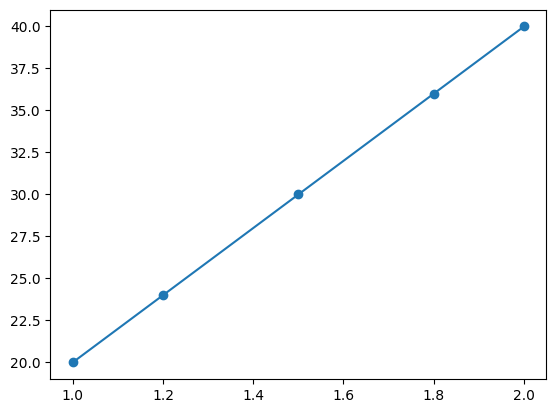

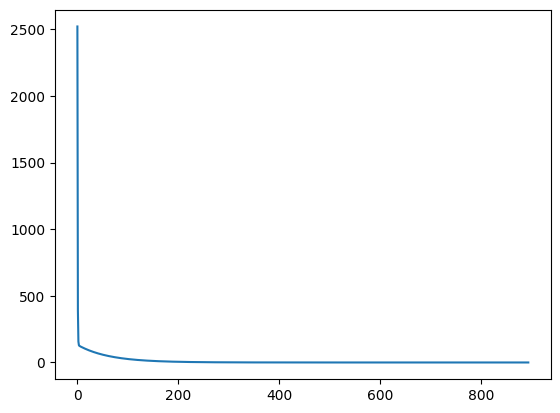

In [ ]:
import numpy as np
import random

class LinearRegressions:
  def __init__(self, learning_rate=0.00001, epochs = 10000, threshold = 1e-6):
    self.w = np.ones()
    self.b = random.randint(1,100)
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.threshold = threshold


  def fit(self, x, y):
    prediction = []
    error=[]
    previous_loss = (1/len(y))*np.sum((y - self.predict(x))**2)
    losses = []
    for epoch in range(self.epochs):
      prediction = self.w * x + self.b
      error = y - prediction

      dw = (-2/len(x)) * np.sum(x * error)
      db = (-2/len(x)) * np.sum(error)

      self.w = self.w - self.learning_rate * dw
      self.b = self.b - self.learning_rate * db

      current_loss = (1/len(y))*np.sum((y - self.predict(x))**2)

      if abs(current_loss - previous_loss) < self.threshold:
        break
      previous_loss = current_loss
      losses.append(current_loss)
    return losses

  def predict(self, x):
    return self.w * x + self.b

  def score(self, x, y):
    return np.mean((y - (self.w * x + self.b))**2)
  def plot(self, x, y):
    plt.scatter(x, y)
    plt.plot(x, self.predict(x))


model = LinearRegressions(0.1, 1000)
x= np.array([1, 1.2, 1.5, 1.8, 2], dtype=float)
y= np.array([20, 24, 30, 36, 40], dtype=float)
losses = model.fit(x, y)
print(model.score(x, y))
print(model.predict(1.7))
model.plot(x, y)
plt.show()
plt.plot(losses)
plt.show()




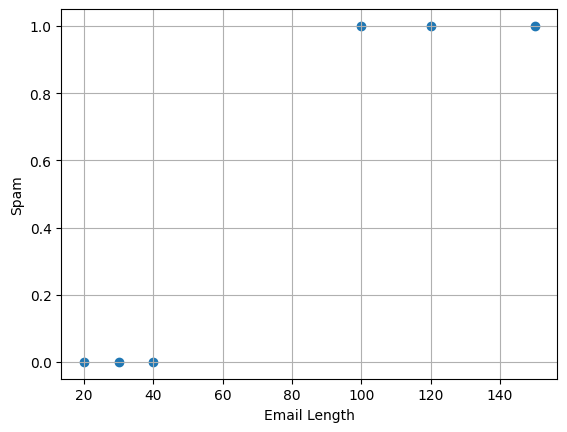

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([20,30,40,100,120,150], dtype=float)
y = np.array([0,0,0,1,1,1], dtype=float)

plt.scatter(x,y)
plt.xlabel("Email Length")
plt.ylabel("Spam")
plt.grid(True)
plt.show()



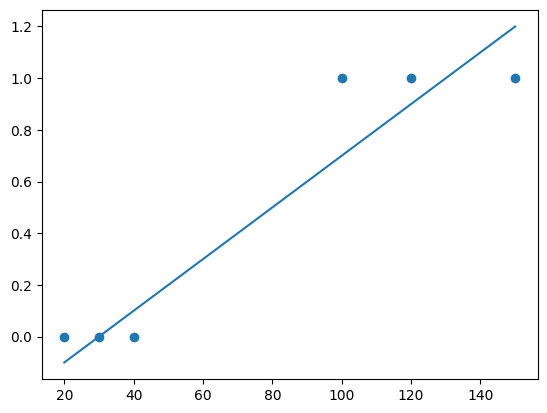

In [ ]:
w = 0.01
b = -0.3

prediction = w*x + b

plt.scatter(x,y)
plt.plot(x,prediction)
plt.show()

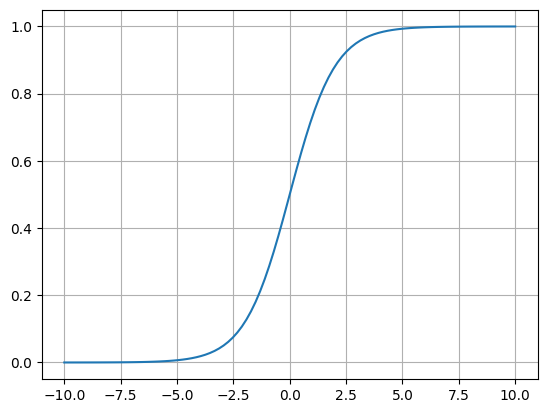

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.grid(True)
plt.show()

In [ ]:
class LogisticRegression:

    def __init__(self, learning_rate = 0.001, epochs = 1000):
        self.w = 0
        self.b = 0
        self.learning_rate = learning_rate
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, x, y):
        error = []
        prediction = []
        for epoch in range(self.epochs):
         prediction = self.sigmoid(self.w * x + self.b)
         error = y - prediction

         dw = (1/len(x)) * np.sum(x * error)
         db = (1/len(x)) * np.sum(error)

         self.w = self.w - self.learning_rate * dw
         self.b = self.b - self.learning_rate * db

    def predict_proba(self, x):

      z  = self.w * x + self.b
      return self.sigmoid(z)

    def binary_cross_entropy(y, p):
       p = np.clip(p, 1e-15, 1 - 1e-15)
       return -(y*np.log(p) + (1-y)*np.log(1-p))



    def predict(self, x, threshold):
        return self.predict_proba(x)

In [ ]:
import numpy as np
model = LogisticRegression(0.1, 1000000)
x= np.array([1, 1.2, 1.5, 1.8, 2], dtype=float)
y= np.array([0, 1, 1, 0, 0], dtype=float)
losses = model.fit(x, y)
print(model.predict(1.8,0.5))




1


In [ ]:
import numpy as np

class LinearRegression: #vectorized

    def __init__(self, learning_rate=1e-3, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, x, y):

        n_samples, n_features = x.shape

        # One weight per feature
        self.w = np.zeros(n_features)
        self.b = 0

        for epoch in range(self.epochs):

            # Predictions
            prediction = x @ self.w + self.b

            # Errors
            error = y - prediction

            # Gradients
            dw = (-2 / n_samples) * (x.T @ error)
            db = (-2 / n_samples) * np.sum(error)

            # Update
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, x):
        return x @ self.w + self.b

    def score(self, x, y):
        prediction = self.predict(x)
        return np.mean((y - prediction) ** 2)

In [ ]:
import numpy as np

class LogisticRegression: #vectorized

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, x, y):

        n_samples, n_features = x.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for epoch in range(self.epochs):

            # Linear prediction
            z = x @ self.w + self.b

            # Probability
            prediction = self.sigmoid(z)

            # Error
            error = prediction - y

            # Gradients
            dw = (1 / n_samples) * (x.T @ error)
            db = (1 / n_samples) * np.sum(error)

            # Update
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict_proba(self, x):
        z = x @ self.w + self.b
        return self.sigmoid(z)

    def predict(self, x, threshold=0.5):
        return (self.predict_proba(x) >= threshold).astype(int)

    def binary_cross_entropy(self, x, y):
        p = self.predict_proba(x)
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -np.mean(
            y * np.log(p) +
            (1 - y) * np.log(1 - p)
        )

Decision Trees

In [ ]:
import numpy as np


# ============================
# Helper Functions
# ============================

def get_split_candidates(x):
    """
    Generate all possible split points.

    Example:
    x = [18,22,25,35]

    candidates:
    20, 23.5, 30
    """

    x = np.sort(x)

    splits = []

    for i in range(len(x) - 1):
        midpoint = (x[i] + x[i + 1]) / 2
        splits.append(midpoint)

    return splits


def gini(y):
    """
    Calculate Gini Impurity.
    """

    classes, counts = np.unique(y, return_counts=True)

    probabilities = counts / len(y)

    return 1 - np.sum(probabilities ** 2)


def weighted_gini(left_y, right_y):
    """
    Calculate weighted gini after a split.
    """

    total = len(left_y) + len(right_y)

    return (
        len(left_y) / total * gini(left_y)
        +
        len(right_y) / total * gini(right_y)
    )


def best_split(x, y):
    """
    Find the threshold that minimizes weighted gini.
    """

    best_threshold = None
    best_score = float("inf")

    for threshold in get_split_candidates(x):

        left_mask = x < threshold
        right_mask = x >= threshold

        left_y = y[left_mask]
        right_y = y[right_mask]

        score = weighted_gini(left_y, right_y)

        if score < best_score:
            best_score = score
            best_threshold = threshold

    return best_threshold


# ============================
# Tree Classes
# ============================

class Leaf:
    """
    Final prediction node.
    """

    def __init__(self, value):
        self.value = value


class Node:
    """
    Decision node.
    """

    def __init__(self, threshold, left, right):

        self.threshold = threshold
        self.left = left
        self.right = right


# ============================
# Decision Tree
# ============================

class DecisionTree:

    def __init__(self):
        self.root = None

    # ------------------------
    # Training
    # ------------------------

    def fit(self, x, y):

        x = np.array(x)
        y = np.array(y)

        self.root = self.build_tree(x, y)

    def build_tree(self, x, y):

        # Base Case 1
        # If every label is identical,
        # create a leaf.

        if len(np.unique(y)) == 1:
            return Leaf(y[0])

        # Base Case 2
        # If no split is possible.

        if len(x) <= 1:
            values, counts = np.unique(y, return_counts=True)
            prediction = values[np.argmax(counts)]
            return Leaf(prediction)

        # Find best threshold

        threshold = best_split(x, y)

        # Split data

        left_mask = x < threshold
        right_mask = x >= threshold

        left_x = x[left_mask]
        left_y = y[left_mask]

        right_x = x[right_mask]
        right_y = y[right_mask]

        # Safety check

        if len(left_x) == 0 or len(right_x) == 0:

            values, counts = np.unique(y, return_counts=True)
            prediction = values[np.argmax(counts)]

            return Leaf(prediction)

        # Recursively build left subtree

        left_child = self.build_tree(left_x, left_y)

        # Recursively build right subtree

        right_child = self.build_tree(right_x, right_y)

        # Return the current node

        return Node(
            threshold,
            left_child,
            right_child
        )

    # ------------------------
    # Prediction
    # ------------------------

    def predict_one(self, x, node):

        # If we've reached a leaf,
        # return its prediction.

        if isinstance(node, Leaf):
            return node.value

        # Otherwise continue down the tree.

        if x < node.threshold:
            return self.predict_one(x, node.left)

        return self.predict_one(x, node.right)

    def predict(self, x):

        x = np.array(x)

        predictions = []

        for value in x:
            predictions.append(
                self.predict_one(value, self.root)
            )

        return np.array(predictions)


x = np.array([18,22,25,35,40,45])
y = np.array([0,0,0,1,1,1])

tree = DecisionTree()

tree.fit(x, y)

print(tree.predict([20]))
print(tree.predict([28]))
print(tree.predict([38]))
print(tree.predict([50]))

[0]
[0]
[1]
[1]
